# A walk-forward on SPY that cannot see the future

One model, end to end, on 25 years of daily SPY: features that are all
lagged, a label that looks five days ahead, a purged walk-forward that
drops the training rows whose labels overlap the test window, a GARCH
fit per fold continued onto the test data, and a volatility-targeted
position sized against the previous close.

The point is the plumbing, not the signal. The signal is a ridge
regression on six textbook features and it earns nothing out of sample,
which is what a six-feature ridge on SPY should earn. The sizing is
worth something. Then the same model is run three more times: twice
with one line changed, to show what each of the two common leaks does
to the number, and once as a control that changes nothing that matters.

Data: `examples/data/SPY.csv`, daily OHLC and dividend-adjusted close
from Yahoo Finance, 2000-01-03 to 2026-09-02, checked in so this runs
offline and gives the same numbers every time.

In [1]:
import numpy as np
import pandas as pd
import walkforward as wf

H = 5                        # each label spans five trading days
TRAIN, TEST = 1260, 126      # five years in, half a year out, then roll
TARGET = 0.10 / np.sqrt(252)  # 10% a year, as a daily figure
MAX_LEVERAGE = 2.0
RIDGE = 1.0

print(wf.__version__)

3.4.1


## Returns, features, label

Everything on the right-hand side for bar `t` must be known at the close
of `t-1`. `rolling_mean`, `rolling_std` and `garman_klass_vol` are
contemporaneous, so each one is passed through `lag`. The label is the
return over bars `t` to `t+4`; it uses the future on purpose, because
that is what a label is.

In [2]:
px = pd.read_csv("data/SPY.csv", index_col="Date", parse_dates=True)
returns = px["AdjClose"].pct_change().dropna()
o, h, l, c = (px[k].loc[returns.index] for k in ("Open", "High", "Low", "Close"))
prev_close = wf.lag(px["AdjClose"]).loc[returns.index]  # the price a position for bar t is entered at

X = pd.DataFrame({
    "r1": wf.lag(returns),
    "m5": wf.lag(wf.rolling_mean(returns, 5)),
    "m21": wf.lag(wf.rolling_mean(returns, 21)),
    "m252": wf.lag(wf.rolling_mean(returns, 252)),
    "v21": wf.lag(wf.rolling_std(returns, 21)),
    "gk": wf.lag(wf.garman_klass_vol(o, h, l, c)),
})
y = (1 + returns).rolling(H).apply(np.prod, raw=True).shift(-(H - 1)) - 1

ok = X.notna().all(axis=1) & y.notna()
X, y, r, prev_close = X[ok], y[ok], returns[ok], prev_close[ok]
print(len(r), "bars from", r.index[0].date(), "to", r.index[-1].date())

6450 bars from 2001-01-03 to 2026-08-27


## The splits

`PurgedWalkForward` takes the label horizon, not a purge count. With
`label_horizon=5` the last four training rows before each test window are
dropped: their labels were computed from prices inside the window.

In [3]:
cv = wf.PurgedWalkForward(train_size=TRAIN, test_size=TEST, label_horizon=H)
first_train, first_test = next(cv.split(X))
print(cv, "gives", cv.get_n_splits(X), "folds")
print("first fold: train ends at row", first_train[-1], ", test starts at row", first_test[0],
      ", gap of", first_test[0] - first_train[-1] - 1, "rows")

PurgedWalkForward(train_size=1260, test_size=126, label_horizon=5) gives 41 folds
first fold: train ends at row 1255 , test starts at row 1260 , gap of 4 rows


## The loop

Per fold: standardise the features with training statistics, fit the
ridge, predict the test window. Then fit a GARCH(1,1) on the training
returns, demeaned with the training mean, and continue its variance
recursion across the purge gap and through the test window with
`filter_from`. The filter is predictive, so `sigma[t]` is the forecast
for bar `t` built from returns before `t`.

In [4]:
def walk_forward(X, purge=H - 1):
    cv = wf.PurgedWalkForward(train_size=TRAIN, test_size=TEST, purge=purge)
    pred = pd.Series(np.nan, index=r.index)
    sigma = pd.Series(np.nan, index=r.index)
    Xv, yv, rv = X.to_numpy(), y.to_numpy(), r.to_numpy()
    for train, test in cv.split(Xv):
        mean, std = Xv[train].mean(axis=0), Xv[train].std(axis=0)
        model = wf.Ridge(ridge=RIDGE).fit((Xv[train] - mean) / std, yv[train])
        pred.iloc[test] = model.predict((Xv[test] - mean) / std)

        mu = rv[train].mean()
        garch = wf.garch_fit(rv[train] - mu)
        path = garch.filter_from(rv[train[-1] + 1 : test[-1] + 1] - mu)
        sigma.iloc[test] = path[-len(test):]
    keep = pred.notna()
    return pred[keep], sigma[keep]


pred, sigma = walk_forward(X)
test_bars = pred.index
print(len(test_bars), "out-of-sample bars,", test_bars[0].date(), "to", test_bars[-1].date())

5166 out-of-sample bars, 2006-01-10 to 2026-07-24


## Sizing

`vol_target_position` returns units: the number of shares that makes the
position's daily volatility equal to the target, capped at
`MAX_LEVERAGE` times equity. It is sized against the previous close,
because that is the price the position is entered at. With equity fixed
at 1, `units * prev_close` is the notional as a fraction of equity and
`notional * r[t]` is the day's return on equity.

In [5]:
units = wf.vol_target_position(sigma, TARGET, 1.0, prev_close[test_bars], MAX_LEVERAGE)
notional = units * prev_close[test_bars]
print("mean notional", round(notional.mean(), 2), "of equity; largest", round(notional.max(), 2))

mean notional 0.74 of equity; largest 1.42


In [6]:
def summary(daily):
    daily = daily.dropna()
    annual_return = daily.mean() * 252
    annual_vol = daily.std() * np.sqrt(252)
    equity = (1 + daily).cumprod()
    return pd.Series({
        "Sharpe": annual_return / annual_vol,
        "annual return": annual_return,
        "annual vol": annual_vol,
        "max drawdown": (equity / equity.cummax() - 1).min(),
    })


strategies = {
    "buy and hold": r[test_bars],
    "vol target, long only": notional * r[test_bars],
    "vol target, ridge signal": np.sign(pred) * notional * r[test_bars],
}
table = pd.DataFrame({k: summary(v) for k, v in strategies.items()}).T
table.round(3)

,Sharpe,annual return,annual vol,max drawdown
buy and hold,0.634,0.122,0.193,-0.552
"vol target, long only",0.785,0.079,0.101,-0.267
"vol target, ridge signal",0.184,0.019,0.101,-0.354


In [7]:
# These are the numbers the README quotes. CI executes this notebook, so a
# change in the library that moves them fails the build.
def expect(frame, row, sharpe, drawdown):
    got = frame.loc[row]
    assert abs(got["Sharpe"] - sharpe) < 1e-3 and abs(got["max drawdown"] - drawdown) < 1e-3, (row, got.to_dict())

expect(table, "buy and hold", 0.634, -0.552)
expect(table, "vol target, long only", 0.785, -0.267)
expect(table, "vol target, ridge signal", 0.184, -0.354)
assert abs(table.loc["vol target, long only", "annual vol"] - 0.101) < 1e-3

Realised volatility lands on the 10% target. On this path the long-only
vol-targeted line beats buy and hold on Sharpe and halves the drawdown,
which is the familiar result that variance forecasts are useful even when
return forecasts are not. The ridge signal, on top of that, subtracts
value: its hit rate is barely above a coin.

In [8]:
hit_rate = (np.sign(pred) == np.sign(y[test_bars])).mean()
correlation = np.corrcoef(pred, y[test_bars])[0, 1]
print(f"hit rate {hit_rate:.3f}, correlation with the label {correlation:.3f}")

hit rate 0.532, correlation with the label 0.044


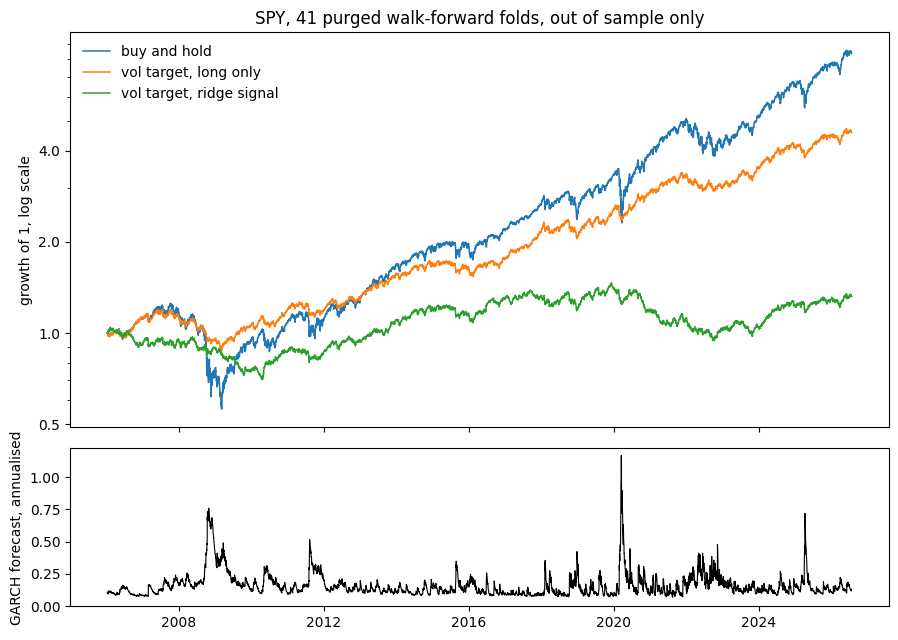

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter, ScalarFormatter

fig, (top, bottom) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1.2]})
for name, daily in strategies.items():
    top.plot((1 + daily).cumprod(), label=name, linewidth=1.1)
top.set_yscale("log")
top.set_yticks([0.5, 1, 2, 4])
top.yaxis.set_major_formatter(ScalarFormatter())
top.yaxis.set_minor_formatter(NullFormatter())
top.set_ylabel("growth of 1, log scale")
top.legend(loc="upper left", frameon=False)
top.set_title("SPY, 41 purged walk-forward folds, out of sample only")
bottom.plot(sigma * np.sqrt(252), color="black", linewidth=0.8)
bottom.set_ylabel("GARCH forecast, annualised")
bottom.set_ylim(0, None)
fig.tight_layout()
fig.savefig("spy_walk_forward.png", dpi=110)

## Two ways to get a better number that is not real

Same features, same folds, same sizing. First, purge nothing, as if the
labels were one day long: the last four training rows of every fold now
carry labels computed from test-window prices. Second, drop every `lag`:
`r1` for bar `t` is now `r[t]` itself, which is one fifth of the label.

A third row is a control. It ends each training window four bars
earlier, which changes the training set by the same number of rows as
the purge does but leaks nothing. It shows how much a single Sharpe
moves when 0.3% of the training rows change for no reason at all.

In [10]:
pred_no_purge, _ = walk_forward(X, purge=0)
pred_shifted, _ = walk_forward(X, purge=2 * (H - 1))

X_unlagged = pd.DataFrame({
    "r1": returns,
    "m5": wf.rolling_mean(returns, 5),
    "m21": wf.rolling_mean(returns, 21),
    "m252": wf.rolling_mean(returns, 252),
    "v21": wf.rolling_std(returns, 21),
    "gk": wf.garman_klass_vol(o, h, l, c),
}).loc[X.index]
pred_unlagged, _ = walk_forward(X_unlagged)

leaks = {
    "honest": strategies["vol target, ridge signal"],
    "no purge": np.sign(pred_no_purge) * notional * r[test_bars],
    "training window ends 4 bars earlier, no leak": np.sign(pred_shifted) * notional * r[test_bars],
    "features not lagged": np.sign(pred_unlagged) * notional * r[test_bars],
}
leak_table = pd.DataFrame({k: summary(v) for k, v in leaks.items()}).T
leak_table.round(3)

,Sharpe,annual return,annual vol,max drawdown
honest,0.184,0.019,0.101,-0.354
no purge,0.265,0.027,0.101,-0.351
"training window ends 4 bars earlier, no leak",0.100,0.010,0.101,-0.378
features not lagged,14.615,1.089,0.075,-0.013


In [11]:
expect(leak_table, "no purge", 0.265, -0.351)
expect(leak_table, "training window ends 4 bars earlier, no leak", 0.100, -0.378)
expect(leak_table, "features not lagged", 14.615, -0.013)

Skipping the purge moves the Sharpe by 0.08. The control moves it by
0.08 the other way while leaking nothing, so on this run the purge's
effect is inside the noise of a single Sharpe. The leak is still real,
by construction, and grows with the label horizon and shrinks with the
test window; it is small at five days against 1260 training rows.
The unlagged features are the change that matters: a Sharpe of 14 from
a model with no edge, and nothing in the code that produced it looks
wrong.

## What to take from this

- Build features for bar `t` from data before `t`; the library's own
  estimators either already do or ship with `lag` and say so.
- Give the splitter the label horizon and let it work out the purge.
- Continue a fitted GARCH with `filter_from`; refitting or restarting the
  filter on the test window alone is the other common mistake.
- Size against the previous close and multiply by it.
- Report the number the honest run gives.